<a href="https://colab.research.google.com/github/adityak714/impact-of-bias-in-fr/blob/7-labelling-race-on-lfw-data-points/running_deepface_lfw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [ ]:
import cv2
import matplotlib.pyplot as plt
import polars as pl
from PIL import Image
import os
import pickle

# ! pip install -U datasets
! pip install deepface
from deepface import DeepFace

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.3/128.3 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.9 MB/s eta 0:00:00
25-10-08 09:46:19 - Directory /root/.deepface has been created
25-10-08 09:46:19 - Directory /root/.deepface/weights has been created


## **Huggingface Key**

In [ ]:
# ! echo "HF_TOKEN=<your token>" > .env
# OR
# ! export HF_TOKEN=<your token>;
# ! cat .env

> DeepFace is a hybrid face recognition package. It currently wraps many state-of-the-art face recognition models: VGG-Face , FaceNet, OpenFace, DeepFace, DeepID, ArcFace, Dlib, SFace, GhostFaceNet and Buffalo_L.

<hr>

# Using the FairFace Dataset
- Images not identifiable, not known which images are whose, and how many images exist of those people.
- Can be found using similarity scores, and sort from highest to lowest.

In [ ]:
# https://github.com/dchen236/FairFace?tab=readme-ov-file
# https://huggingface.co/datasets/ryanramos/fairface

from datasets import load_dataset
ds = load_dataset("ryanramos/fairface", "margin025")

README.md: 0.00B [00:00, ?B/s]

margin025/train-00000-of-00002.parquet:   0%|          | 0.00/250M [00:00<?, ?B/s]

margin025/train-00001-of-00002.parquet:   0%|          | 0.00/250M [00:00<?, ?B/s]

margin025/val-00000-of-00001.parquet:   0%|          | 0.00/63.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/86744 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/10954 [00:00<?, ? examples/s]

In [ ]:
train = ds["train"]
val = ds["val"]

In [ ]:
train[0]

{'file': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=224x224>,
 'age': '50-59',
 'gender': 'Male',
 'race': 'East Asian',
 'service_test': True}

## Ethnicity

In [ ]:
import shutil
shutil.rmtree('indians', ignore_errors=True)
shutil.rmtree('east_asians', ignore_errors=True)
shutil.rmtree('caucasians', ignore_errors=True)

### Indians

In [ ]:
# Deepface only accepts base64 images or raw paths to downloaded images
# So PIL images from the HF datasets library, are converted to base64.

if not os.path.isdir("indians"):
  indians = train.filter(lambda x: x["race"] == "Indian")
  os.mkdir("indians")
  for i in range(len(indians)):
    # initially was supposed to be a small value e.g. 50,
    # but should be done for all in the train dataset of FairFace
    # all matching the "indian" ethnicity
    indians[i]["file"].save(f'indians/{i+1}.png')

Filter:   0%|          | 0/86744 [00:00<?, ? examples/s]

{'file': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=224x224 at 0x7D002E8BB500>, 'age': '10-19', 'gender': 'Female', 'race': 'Indian', 'service_test': True}


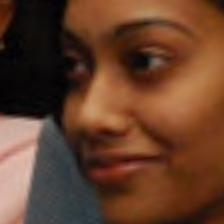

In [ ]:
print(indians[9]) # an example of an object's attributes from dataset
Image.open("indians/3018.png") # VGGFace had detection issue for this, as an example.

In [ ]:
images = os.listdir("indians")
model = "Facenet512"
indian_embedded = []
# not_embedded = []

for image in images[:500]:
  try:
    indian_embedded.append(DeepFace.represent(f'indians/{image}', model_name=model)) # VGGFace by default
  except ValueError:
    print(f"error with image >>", image) # here, detection phase was unsuccessful
    # 500 images -> 300 successfully get embedded
    # not_embedded.append(image)

In [ ]:
print(len(indian_embedded))
print(model, "<<<< embedding_dim =", len(indian_embedded[0][0]["embedding"]))
# first dim: which image,
# second dim: nested duplicate, [just use index 0]
# third dim: embedding, similarity score, or which attribute (it is of type dict)

A1 = np.array([item[0]["embedding"] for item in indian_embedded], dtype='float64')

350
Facenet512 <<<< embedding_dim = 512


In [ ]:
# %matplotlib widget
import numpy as np

# Code for reducing based on how many principal components to preserve (PCA)
# as the image embeddings are high-dimensional, bring it down to a 3-d map for viz
def reduce_SVD(A, r): # A: your matrix, r: how many principal components
  U, S, Vt = np.linalg.svd(A)
  reduced_U = U[:,:r]
  reduced_S = S[:r]
  reduced_Vt = Vt[:r,:]
  print(np.shape(reduced_U), np.shape(reduced_S), np.shape(reduced_Vt))
  reduced_A = np.dot(reduced_U * reduced_S, reduced_Vt)
  return reduced_A

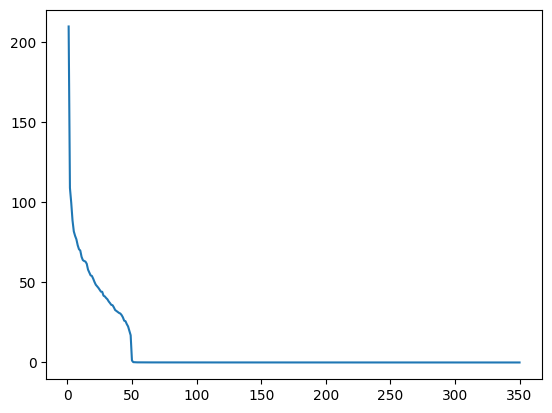

In [ ]:
# enter your code here
U, S, Vt = np.linalg.svd(A1)

x = np.arange(1,len(S)+1)
plt.plot(x,S) # collection of a bit less than 400 singular eigenvals

In [ ]:
P2_1 = reduce_SVD(A1.T,r=2)
# ax.scatter3D(P2[0,:], P2[1,:], P2[2,:], color = 'red', marker ='.')

(512, 2) (2,) (2, 350)


### East-Asians

In [ ]:
# Deepface only accepts base64 images or raw paths to downloaded images
# So PIL images from the HF datasets library, are converted to base64.

if not os.path.isdir("east_asians"):
  east_asians = train.filter(lambda x: x["race"] == "East Asian")
  os.mkdir("east_asians")
  for i in range(500): # len(east_asians)
    # initially was supposed to be a small value e.g. 50,
    # but should be done for all in the train dataset of FairFace
    # all matching the "indian" ethnicity
    east_asians[i]["file"].save(f'east_asians/{i+1}.png')

images = os.listdir("east_asians")
model = "Facenet512"
eastasian_embedded = []

for image in images:
  try:
    eastasian_embedded.append(DeepFace.represent(f'east_asians/{image}', model_name=model)) # VGGFace by default
  except ValueError:
    print(f"error with image >>", image) # here, detection phase was unsuccessful

print(len(eastasian_embedded)) # images that could be detected and represented
print(model, "<<<< embedding_dim =", len(eastasian_embedded[0][0]["embedding"]))

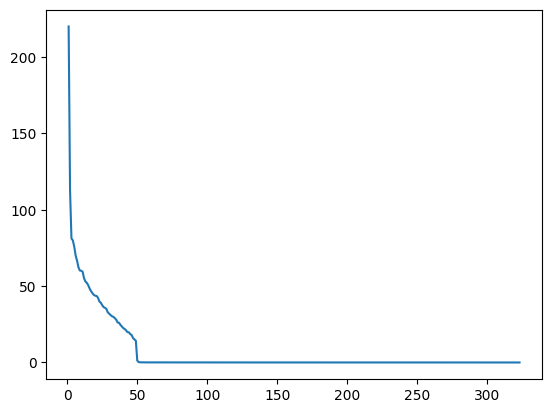

In [ ]:
# enter your code here
A2 = np.array([item[0]["embedding"] for item in eastasian_embedded], dtype='float64')
U, S, Vt = np.linalg.svd(A2)

# TODO
k = 3
# Suppose S is the vector of singular values from SVD
# Fraction of variance explained by each component
explained_variance_ratio = S**2 / np.sum(S**2)

# Cumulative variance explained
# Check how much variance is explained by first k components
cumulative_variance = np.cumsum(explained_variance_ratio)
print(f"Variance explained by first {k} components: {cumulative_variance[k-1]:.4f}")

x = np.arange(1,len(S)+1) # TODO: Check percentage of how much variance was captured.
plt.plot(x,S) # collection of a bit less than 400 singular eigenvals

In [ ]:
"""
A2_matched = A2[:len(A1), :]
A2_matched.shape
"""
print(A1.shape) # Indians
print(A2.shape) # East-asians

(350, 512)
(323, 512)


(323, 512)

(512, 2) (2,) (2, 323)


Text(0.5, 0.92, 'Indians, East Asians - Graphical Representation of Embeddings')

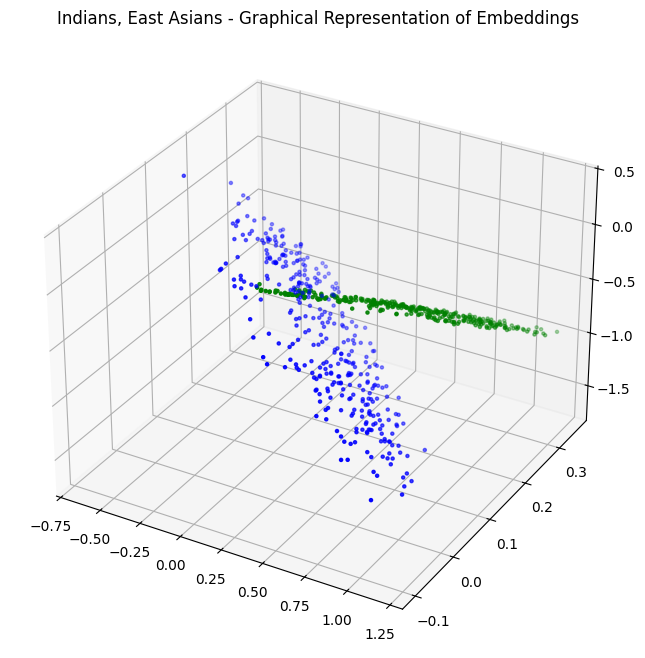

In [ ]:
A2_matched = A2[:len(A1), :]

P2_2 = reduce_SVD(A2_matched.T,r=2)
fig = plt.figure(figsize = (8, 8))
ax = plt.axes(projection ="3d")
ax.scatter3D(P2_1[0,:], P2_1[1,:], P2_1[2,:], color='blue', marker ='.') # Indians -> slightly lower inter-similarity to East Asians
ax.scatter3D(P2_2[0,:], P2_2[1,:], P2_2[2,:], color='green', marker ='.') # East-Asians -> higher inter-similarity
plt.title("Indians, East Asians - Graphical Representation of Embeddings")

### Whites

In [ ]:
# Deepface only accepts base64 images or raw paths to downloaded images
# So PIL images from the HF datasets library, are converted to base64.

if not os.path.isdir("caucasians"):
  caucasians = train.filter(lambda x: x["race"] == "White")
  os.mkdir("caucasians")
  for i in range(500): # len(caucasians)
    caucasians[i]["file"].save(f'caucasians/{i+1}.png')

images = os.listdir("caucasians")
model = "Facenet512"
caucasians_embedded = []

for image in images:
  try:
    caucasians_embedded.append(DeepFace.represent(f'caucasians/{image}', model_name=model)) # VGGFace by default
  except ValueError:
    print(f"error with image >>", image) # here, detection phase was unsuccessful

print(len(caucasians_embedded)) # images that could be detected and represented
print(model, "<<<< embedding_dim =", len(caucasians_embedded[0][0]["embedding"]))

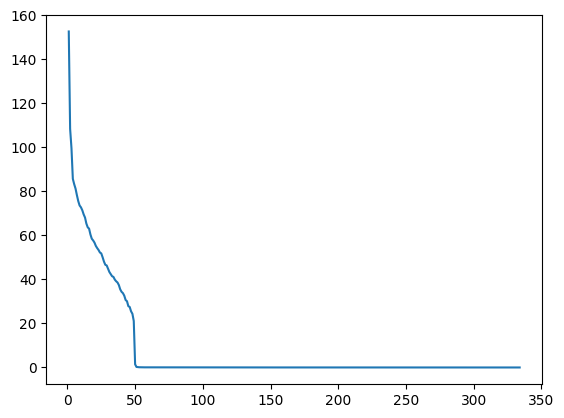

In [ ]:
# enter your code here
A3 = np.array([item[0]["embedding"] for item in caucasians_embedded], dtype='float64')
U, S, Vt = np.linalg.svd(A3)

x = np.arange(1,len(S)+1)
plt.plot(x,S) # collection of a bit less than 400 singular eigenvals

(512, 2) (2,) (2, 334)


Text(0.5, 0.92, 'Indian, East Asian, and White Faces - Graphical representation')

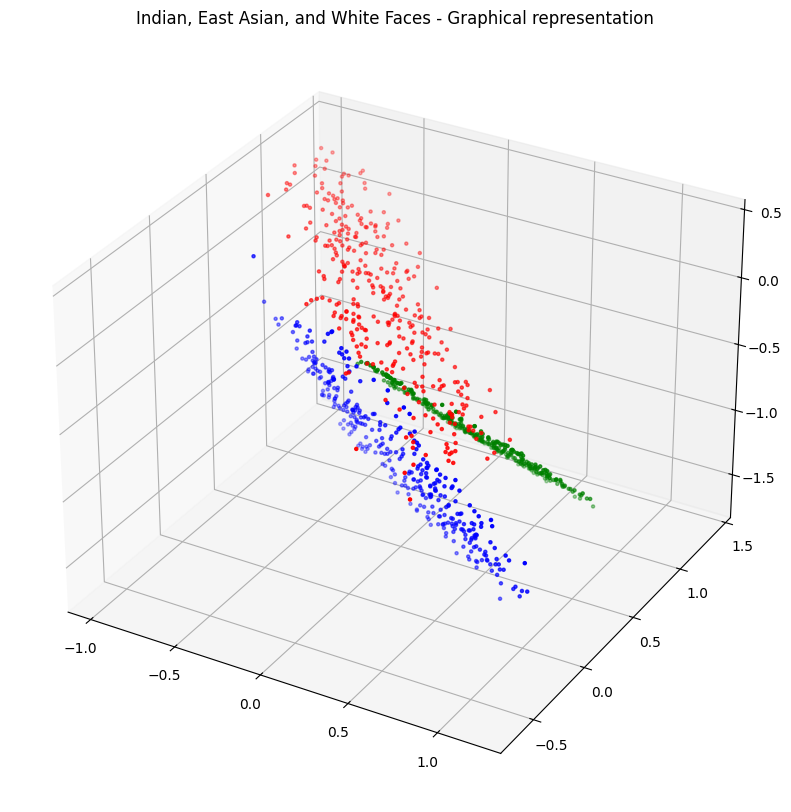

In [ ]:
A3_matched = A3[:len(A1), :]
P2_3 = reduce_SVD(A3_matched.T,r=2)

# If you want to plot in the same axes, to e.g. compare races, ages etc. then comment the following line
fig = plt.figure(figsize = (10, 10))
ax = plt.axes(projection = "3d")

ax.scatter3D(P2_1[0,:], P2_1[1,:], P2_1[2,:], color='blue', marker ='.') # Indians
ax.scatter3D(P2_2[0,:], P2_2[1,:], P2_2[2,:], color='green', marker ='.') # East-Asians
ax.scatter3D(P2_3[0,:], P2_3[1,:], P2_3[2,:], color='red', marker ='.') # Caucasians (White)

plt.title("Indian, East Asian, and White Faces - Graphical representation")

## Age

In [ ]:
# DLib and MediaPipe seem to do facial alignment and cropping differently
# They might have less bias between faces of different ethnicities (hypothesis?)
# Effect of face crop area on race inter-similarity

## Gender

<hr/>

# Using the LFW Dataset

In [ ]:
# https://huggingface.co/datasets/bitmind/lfw
# If using the LFW dataset

from datasets import load_dataset
ds = load_dataset("bitmind/lfw")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/574 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/188M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/13233 [00:00<?, ? examples/s]

In [ ]:
# TBD -> make more hypothesis
# 2 graphs -> 1 graph: the embeddings of the same person's images
#          -> graph #2: the embeddings from graph 1 + other people's embeddings, to see how well they cluster, group up etc.

German_Khan_0001.jpg


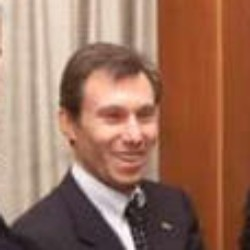

In [ ]:
print(ds["train"][0]['filename'])
ds["train"][0]['image']

In [ ]:
lfw = ds["train"]

# A way to find which people have N number of photos
lfw_min20_photos = lfw.filter(lambda x: "0020" in x['filename'])

Filter:   0%|          | 0/13233 [00:00<?, ? examples/s]

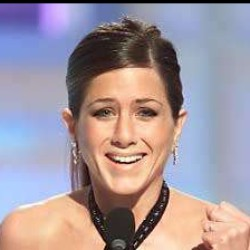

In [ ]:
# roughly 158 people have 10 images of themselves.
# roughly 96 people have 15 images of themselves.
# roughly 62 people have 20 images of themselves.
people = [i for i in lfw_min20_photos['filename']]
lfw_min20_photos['image'][0]
#person1 = lfw_min20_photos.filter(lambda x: )

In [ ]:
person = people[0].split('0')[0] # just extract the name
person_images = lfw.filter(lambda x: person in x["filename"]) # find all matching images with that name
person_images[0]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=250x250>,
 'filename': 'Jennifer_Aniston_0010.jpg'}

In [ ]:
import os

os.mkdir("intra-sim")
for idx, p in enumerate(people):
  person = p.split('0')[0]
  person_images = lfw.filter(lambda x: person in x["filename"])
  os.mkdir(f'intra-sim/{idx}')
  for i, image in enumerate(person_images):
    image["image"].save(f'intra-sim/{idx}/{person}{i+1}.png')

In [ ]:
! pip install mediapipe
! pip install deepface

In [ ]:
import glob
from deepface import DeepFace
backends = [
    'opencv', 'ssd', 'dlib', 'mtcnn',
    'retinaface', 'mediapipe'
]

results = {}
for backend in backends:
  results[backend] = []

for i in range(15):
  images = glob.glob(f'intra-sim/{i}/*.png')
  for detector in backends:
    for image in images:
      try:
        objs = DeepFace.analyze(
          img_path = image, detector_backend = detector, actions = ['race']
        )
        results[detector].append({image: objs})
      except Exception as e:
        print(f"error with image >>", image, e) # here, detection phase was unsuccessful
        # 500 images -> 300 successfully get embedded
        # not_embedded.append(image)

In [ ]:
results

In [ ]:
f = open("result.json")
json_str = f.read().replace("'", '"').replace("None", '"None"')

In [ ]:
with open('results.pickle', 'wb') as file_:
    pickle.dump(results, file_, protocol=pickle.HIGHEST_PROTOCOL)

# data = json.loads(json_str)
# results['opencv'][0].get(list(results['opencv'][0].keys())[0])[0]
#data

In [ ]:
with open('results.pickle', 'rb') as pfile:
    lfw_race_labels = pickle.load(pfile)
print(results == lfw_race_labels) # confirm they are the same

True
